# Seminar on MLLMs Agents

<details>
<summary><b>Why was it hard to train agents a few years ago?</b></summary>

Agents are hard to train because you cannot get robust real-world behavior just by throwing RL at sparse-reward environments

</details>

<details>
<summary><b>How did we solve the problem?</b></summary>

The problem was overcome by pretraining models first to acquire broad knowledge and internal representations, then adding agentic behavior or RL on top, rather than starting from pure trial-and-error interaction.

</details>

**"Agent"** can be defined in several ways. Some customers define agents as fully autonomous systems that operate independently over extended periods, using various tools to accomplish complex tasks. Others use the term to describe more prescriptive implementations that follow predefined workflows. At Anthropic, we categorize all these variations as agentic systems, but draw an important architectural distinction between workflows and agents:

**Workflows** are systems where LLMs and tools are orchestrated through predefined code paths.
**Agents**, on the other hand, are systems where LLMs dynamically direct their own processes and tool usage, maintaining control over how they accomplish tasks.

[link](https://www.anthropic.com/engineering/building-effective-agents)

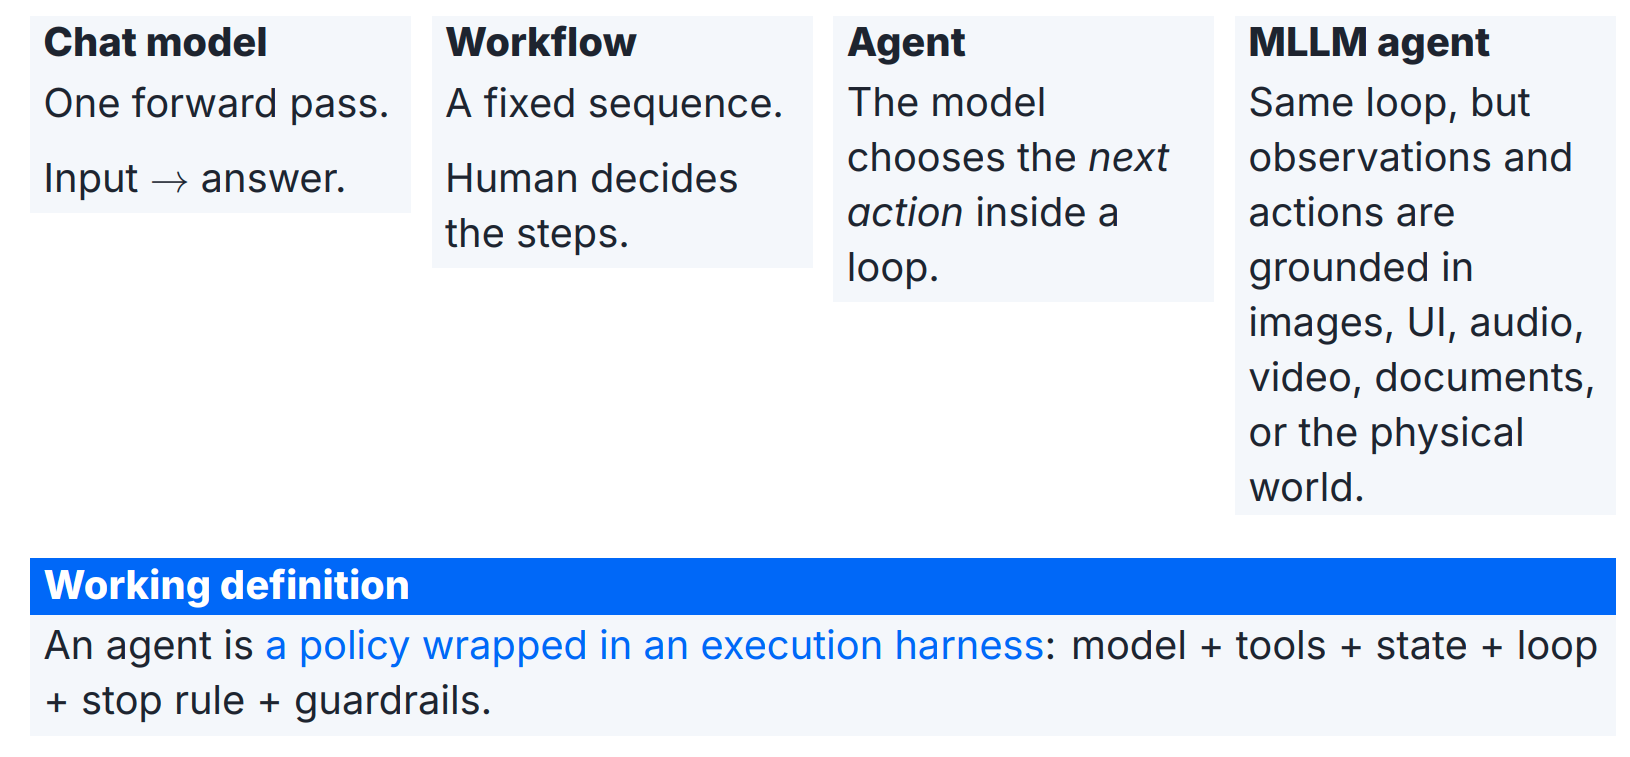

Classical Agent Loop

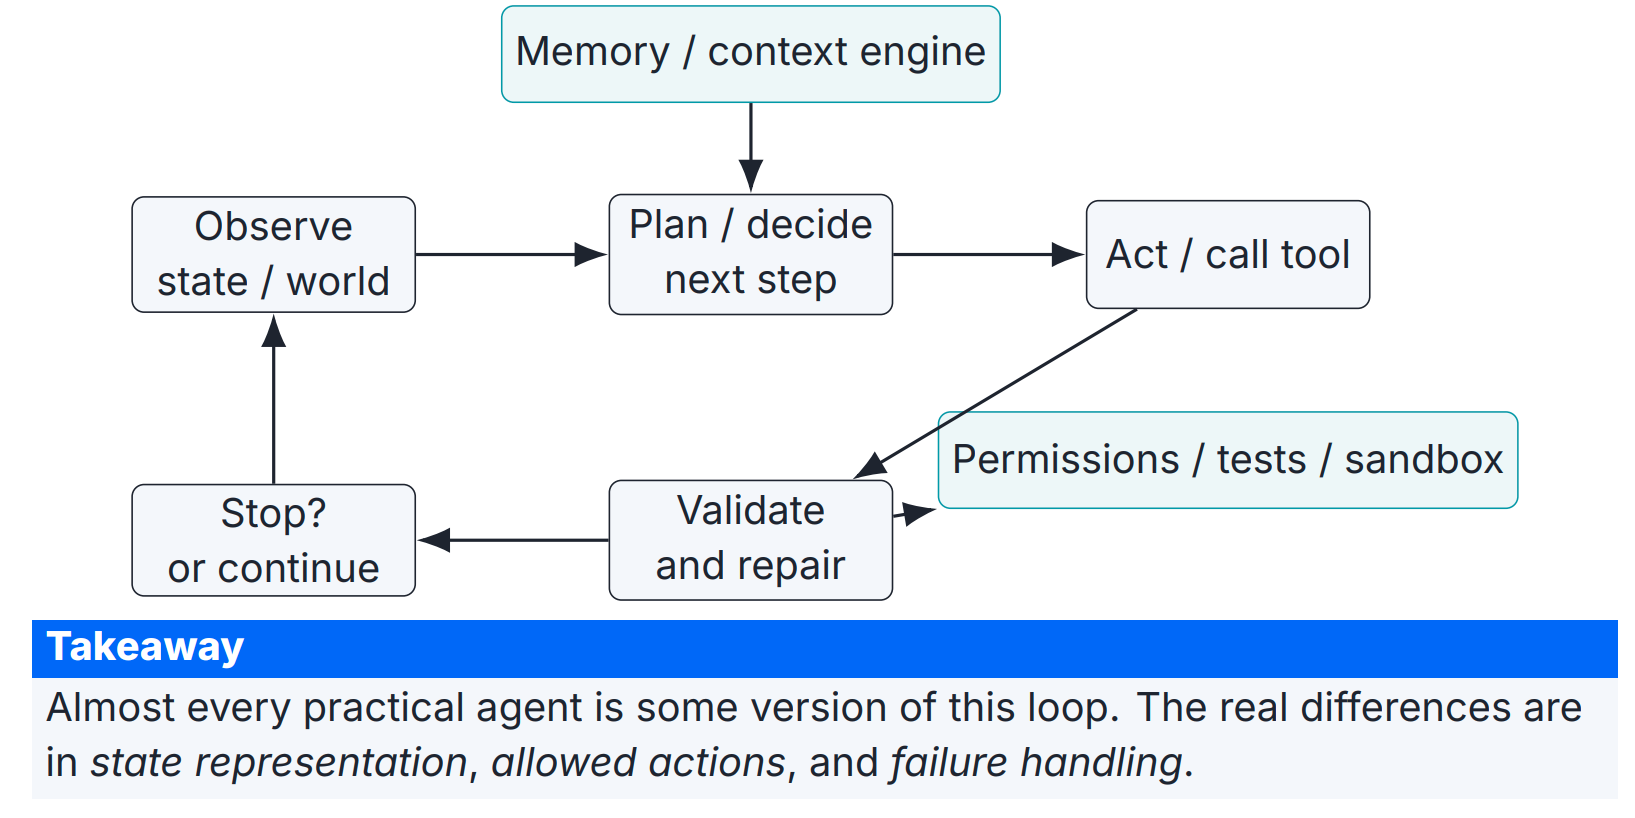

Anatomy of Modern Agent Systems

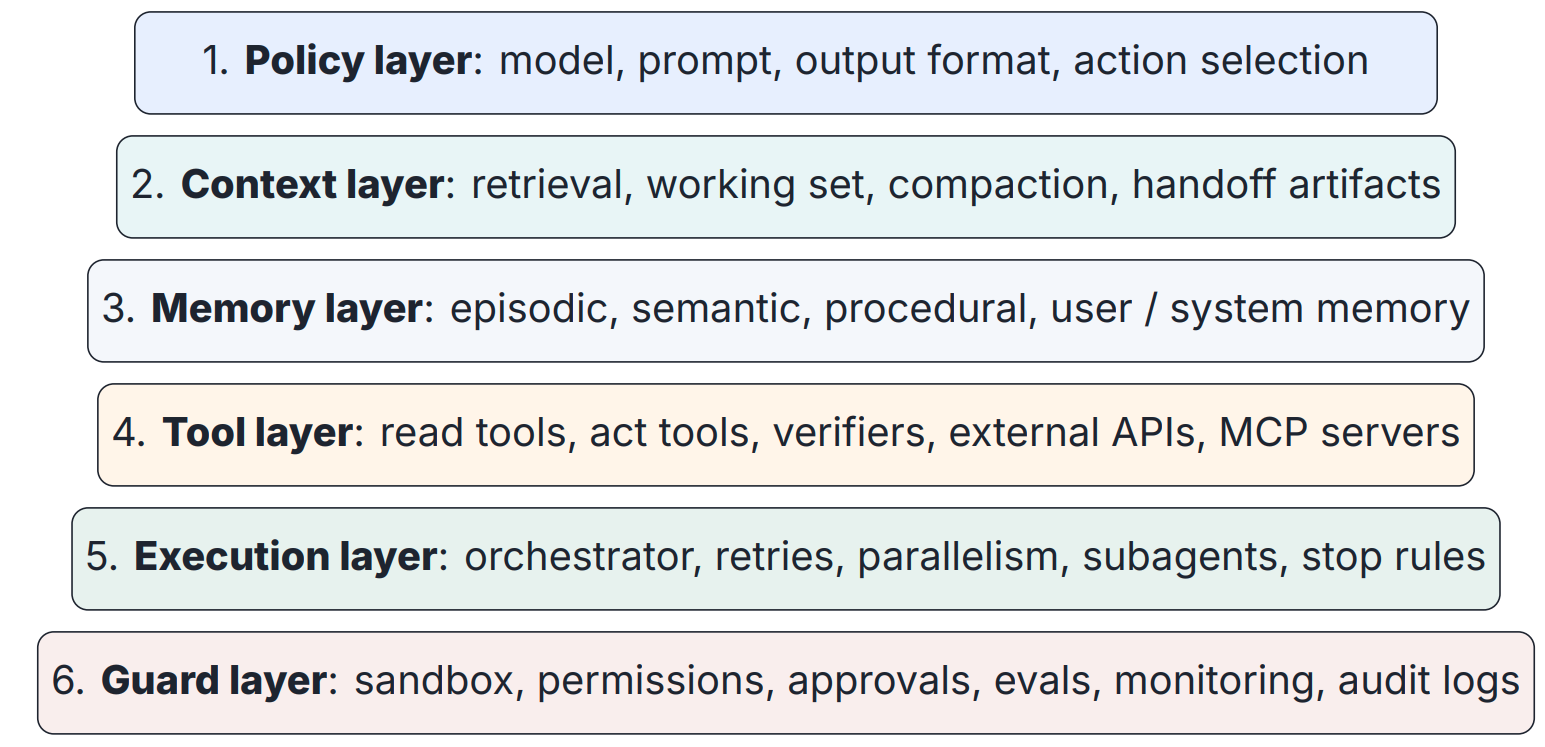


1. **Visual chess agent**
   - input: an image of the chess board + side to play
   - output: the next move
   - environment: a real chess board with move validation
   - opponent: Stockfish configured to play at a moderate strength
   - artifact: an animated GIF of the game

2. **Web research agent**
   - input: a text query
   - output: a final answer with source traces
   - loop: search -> inspect links -> summarize -> decide whether to stop or continue
   - stop criterion: the agent thinks it has enough information, or it has visited 5 links



## Practical note before the chess demo

A **board image alone is not a fully sufficient state representation** for chess because some legal moves depend on hidden history:

- castling rights,
- en passant,
- move counters.

So in this notebook the agent receives:

- the **board image**,
- the **side to move**,
- the **recent move history**.

That is actually a nice teaching point: many agents work in **partially observable environments**, so they need both perception and state tracking.


In [ ]:
!nvidia-smi

Wed Apr 15 12:23:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   62C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
%pip -q install -U git+https://github.com/huggingface/transformers accelerate bitsandbytes pillow==11.0.0 matplotlib pandas requests trafilatura ddgs python-chess cairosvg imageio beautifulsoup4 lxml


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 104.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Choice of a VLM and model configuration

Default is Qwen3-VL family.


In [ ]:
# Main libraries import

import gc
import io
import json
import os
import random
import re
import shutil
import textwrap
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional

import imageio.v2 as imageio
import cairosvg
import matplotlib.pyplot as plt
import pandas as pd
import requests
import torch
import trafilatura
from PIL import Image, ImageDraw, ImageFont
from IPython.display import Markdown, display
from bs4 import BeautifulSoup
from ddgs import DDGS
from transformers import BitsAndBytesConfig

import chess
import chess.engine
import chess.pgn
import chess.svg

os.environ["TOKENIZERS_PARALLELISM"] = "false"

ROOT = Path.cwd() / "vlm_agent_workflows"
ROOT.mkdir(parents=True, exist_ok=True)
CHESS_DIR = ROOT / "chess"
WEB_DIR = ROOT / "web"
CHESS_DIR.mkdir(exist_ok=True)
WEB_DIR.mkdir(exist_ok=True)

FONT = ImageFont.load_default()

print("Working directory:", ROOT)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print("GPU:", props.name)
    print("GPU memory (GB):", round(props.total_memory / 1024**3, 2))

def maybe_quant_config(use_4bit: bool = True):
    if not use_4bit or not torch.cuda.is_available():
        return None
    return BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16,
    )

def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def get_model_device(model) -> torch.device:
    try:
        return next(model.parameters()).device
    except StopIteration:
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def model_family(model_id: str) -> str:
    mid = model_id.lower()
    if "qwen3-vl" in mid:
        return "qwen3_vl"
    if "qwen2.5-vl" in mid or "qwen2_5_vl" in mid:
        return "qwen25_vl"
    if "smolvlm" in mid:
        return "smolvlm"
    return "generic"

def image_content_block(model_id: str, image_path: str | Path) -> Dict[str, Any]:
    family = model_family(model_id)
    path = Path(image_path).resolve()
    # Use the local path string directly to avoid URI/base64 decoding issues in the processor
    return {"type": "image", "image": str(path)}

def build_messages(
    prompt: str,
    image_paths: Optional[List[str | Path]] = None,
    system_prompt: Optional[str] = None,
) -> List[Dict[str, Any]]:
    messages: List[Dict[str, Any]] = []
    if system_prompt:
        messages.append({"role": "system", "content": [{"type": "text", "text": system_prompt}]})
    user_content = []
    if image_paths:
        for p in image_paths:
            user_content.append(image_content_block(MODEL_ID, p))
    user_content.append({"type": "text", "text": prompt})
    messages.append({"role": "user", "content": user_content})
    return messages

Working directory: /content/vlm_agent_workflows
Torch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory (GB): 14.56


In [ ]:
# Model configuration

MODEL_ID = os.environ.get("MODEL_ID", "Qwen/Qwen3-VL-8B-Instruct")
# Good alternatives:
# MODEL_ID = "Qwen/Qwen3-VL-8B-Instruct"
# MODEL_ID = "Qwen/Qwen2.5-VL-7B-Instruct"
# MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"
# MODEL_ID = "HuggingFaceTB/SmolVLM2-2.2B-Instruct"

USE_4BIT = True
MAX_NEW_TOKENS_DEFAULT = 256
DO_SAMPLE = False
SEED = 42
random.seed(SEED)

def preferred_dtype() -> torch.dtype:
    if not torch.cuda.is_available():
        return torch.float32
    return torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

DTYPE = preferred_dtype()
print("Model:", MODEL_ID)
print("Preferred dtype:", DTYPE)


Model: Qwen/Qwen3-VL-8B-Instruct
Preferred dtype: torch.bfloat16


In [ ]:
# Model load

clear_memory()

def load_vlm(model_id: str, use_4bit: bool = True):
    family = model_family(model_id)
    quant_config = maybe_quant_config(use_4bit)

    # Ensure offload directory exists
    offload_dir = ROOT / "offload"
    offload_dir.mkdir(exist_ok=True)

    common_kwargs = {
        "device_map": "auto",
        "trust_remote_code": True,
        "offload_folder": str(offload_dir),
    }
    if quant_config is not None:
        common_kwargs["quantization_config"] = quant_config
    else:
        # Updated 'torch_dtype' to 'dtype' to resolve the deprecation warning
        common_kwargs["dtype" ] = DTYPE

    if torch.cuda.is_available() and family in {"qwen3_vl", "qwen25_vl"}:
        common_kwargs["attn_implementation"] = "sdpa"

    if family == "qwen3_vl":
        from transformers import Qwen3VLForConditionalGeneration, AutoProcessor

        model = Qwen3VLForConditionalGeneration.from_pretrained(model_id, **common_kwargs)
        processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)
    elif family == "qwen25_vl":
        from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor

        model = Qwen2_5_VLForConditionalGeneration.from_pretrained(model_id, **common_kwargs)
        processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)
    else:
        from transformers import AutoModelForImageTextToText, AutoProcessor

        model = AutoModelForImageTextToText.from_pretrained(model_id, **common_kwargs)
        processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)

    model.eval()
    return model, processor, family

model, processor, MODEL_FAMILY = load_vlm(MODEL_ID, use_4bit=USE_4BIT)
print("Loaded model family:", MODEL_FAMILY)
print("Model device:", get_model_device(model))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

Loaded model family: qwen3_vl
Model device: cuda:0


In [ ]:
# Inference helpers

def _move_inputs_to_device(inputs, model):
    device = get_model_device(model)
    if hasattr(inputs, "to"):
        try:
            return inputs.to(device)
        except TypeError:
            return inputs.to(device=device)
    moved = {}
    for key, value in inputs.items():
        moved[key] = value.to(device) if hasattr(value, "to") else value
    return moved


def generate_from_messages(
    messages: List[Dict[str, Any]],
    max_new_tokens: int = MAX_NEW_TOKENS_DEFAULT,
    do_sample: bool = DO_SAMPLE,
    temperature: float = 0.2,
) -> str:
    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    )
    inputs.pop("token_type_ids", None)
    inputs = _move_inputs_to_device(inputs, model)

    gen_kwargs = {
        "max_new_tokens": max_new_tokens,
        "do_sample": do_sample,
    }
    if do_sample:
        gen_kwargs["temperature"] = temperature

    with torch.inference_mode():
        output_ids = model.generate(**inputs, **gen_kwargs)

    trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs["input_ids"], output_ids)]
    text = processor.batch_decode(
        trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]
    return text.strip()


def ask_model(
    prompt: str,
    image_paths: Optional[List[str | Path]] = None,
    system_prompt: Optional[str] = None,
    max_new_tokens: int = MAX_NEW_TOKENS_DEFAULT,
) -> str:
    messages = build_messages(prompt=prompt, image_paths=image_paths, system_prompt=system_prompt)
    return generate_from_messages(messages, max_new_tokens=max_new_tokens)


In [ ]:
# Helper functions

def show_image(path: str | Path, title: Optional[str] = None, figsize=(6, 6)):
    image = Image.open(path)
    plt.figure(figsize=figsize)
    plt.imshow(image)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


def extract_json_object(text: str) -> Optional[Dict[str, Any]]:
    text = text.strip()
    if text.startswith("```"):
        text = re.sub(r"^```(?:json)?", "", text).strip()
        text = re.sub(r"```$", "", text).strip()

    candidates = []
    for start in [m.start() for m in re.finditer(r"\{", text)]:
        for end in [m.end() for m in re.finditer(r"\}", text[start:])]:
            snippet = text[start:start + end]
            candidates.append(snippet)
    candidates = sorted(set(candidates), key=len)

    for candidate in candidates:
        try:
            return json.loads(candidate)
        except Exception:
            pass
    return None


def truncate(text: str, max_chars: int = 1200) -> str:
    text = re.sub(r"\s+", " ", text).strip()
    if len(text) <= max_chars:
        return text
    return text[: max_chars - 3].rstrip() + "..."


# Example 1 — Visual chess agent

This section contains **two versions** of the chess demo:

1. **Single-position demo**
2. **Full agent loop** — board image -> move proposal -> legality check -> repair -> play against Stockfish -> GIF

---

## Important design choice

You can run the chess agent in three modes:

- `pure_vision`: the VLM must propose a move directly from the board image
- `legal_tool`: the VLM sees the board image **and** the list of legal moves
- `adaptive`: try pure vision first, then reveal the legal move list only if the first proposal is illegal

Install Stockfish

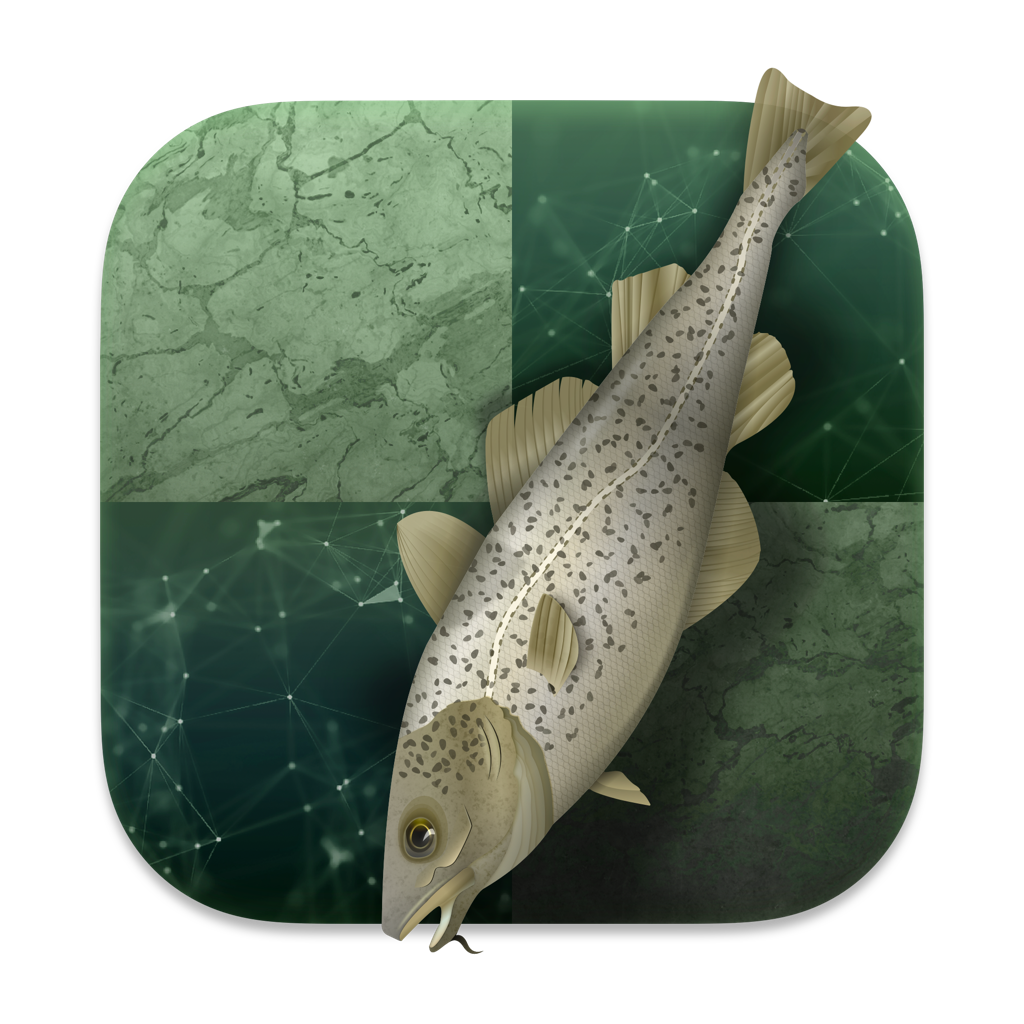


In [ ]:
!apt-get install stockfish

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Suggested packages:
  polyglot xboard | scid
The following NEW packages will be installed:
  stockfish
0 upgraded, 1 newly installed, 0 to remove and 42 not upgraded.
Need to get 24.8 MB of archives.
After this operation, 47.4 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 stockfish amd64 14.1-1 [24.8 MB]
Fetched 24.8 MB in 4s (6,882 kB/s)
Selecting previously unselected package stockfish.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../stockfish_14.1-1_amd64.deb ...
Unpacking stockfish (14.1-1) ...
Setting up stockfish (14.1-1) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
# find stockfish

def guess_stockfish_path() -> Optional[str]:
    candidates = [
        os.environ.get("STOCKFISH_PATH"),
        shutil.which("stockfish"),
        "/usr/games/stockfish",
        "/usr/local/bin/stockfish",
        "/opt/homebrew/bin/stockfish",
    ]
    for candidate in candidates:
        if candidate and Path(candidate).exists():
            return str(candidate)
    return None


STOCKFISH_PATH = guess_stockfish_path()
print("Detected Stockfish:", STOCKFISH_PATH)


Detected Stockfish: /usr/games/stockfish


In [ ]:
# rendering helper functions

def wrap_text_lines(lines: List[str], width: int = 72) -> List[str]:
    wrapped: List[str] = []
    for line in lines:
        wrapped.extend(textwrap.wrap(line, width=width) or [""])
    return wrapped


def render_board_png(
    board: chess.Board,
    out_path: str | Path,
    last_move: Optional[chess.Move] = None,
    orientation: chess.Color = chess.WHITE,
    size: int = 480,
    footer_lines: Optional[List[str]] = None,
):
    svg = chess.svg.board(
        board=board,
        size=size,
        coordinates=True,
        orientation=orientation,
        lastmove=last_move,
        check=board.king(board.turn) if board.is_check() else None,
    )
    png_bytes = cairosvg.svg2png(bytestring=svg.encode("utf-8"))
    board_img = Image.open(io.BytesIO(png_bytes)).convert("RGB")

    max_footer_rows = 8
    line_height = 18
    fixed_footer_height = line_height * max_footer_rows + 20

    canvas = Image.new("RGB", (board_img.width, board_img.height + fixed_footer_height), "white")
    canvas.paste(board_img, (0, 0))

    if footer_lines:
        footer_lines = wrap_text_lines(footer_lines, width=68)[:max_footer_rows]
        draw = ImageDraw.Draw(canvas)
        y = board_img.height + 8
        for line in footer_lines:
            draw.text((10, y), line, fill="black", font=FONT)
            y += line_height

    out_path = Path(out_path)
    canvas.save(out_path)
    return out_path

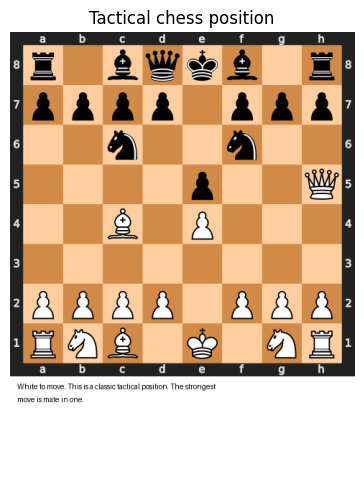

In [ ]:
# Tactical chess position from a FEN string

TACTICAL_FEN = "r1bqkb1r/pppp1ppp/2n2n2/4p2Q/2B1P3/8/PPPP1PPP/RNB1K1NR w KQkq - 3 4"
board = chess.Board(TACTICAL_FEN)
TACTICAL_IMAGE = CHESS_DIR / "tactical_position.png"
render_board_png(
    board,
    TACTICAL_IMAGE,
    footer_lines=["White to move. This is a classic tactical position. The strongest move is mate in one."],
)
show_image(TACTICAL_IMAGE, title="Tactical chess position")


In [ ]:
# Prompting

CHESS_SYSTEM_PROMPT = (
    "You are a careful multimodal chess assistant. "
    "You receive a chess board image and optional state hints. "
    "Return only compact structured answers."
)


def chess_prompt_for_position(
    color_name: str,
    recent_moves_san: List[str],
    mode: str = "pure_vision",
    legal_move_lines: Optional[List[str]] = None,
    feedback: Optional[str] = None,
) -> str:
    prompt = f"""
You are playing as {color_name}.
The image shows the current board. White is at the bottom and coordinates are visible.
Recent SAN moves: {recent_moves_san[-10:] if recent_moves_san else '[]'}
Task: choose the best move for the side to move.
Return valid JSON only:
{{"move_uci": "...", "reason": "...", "confidence": 0.0}}
Use UCI notation like e2e4 or e7e8q.
""".strip()

    if feedback:
        prompt += f"\n\nFeedback from the environment: {feedback}"

    if mode in {"legal_tool", "adaptive_with_legal_list"} and legal_move_lines:
        prompt += "\n\nYou may only choose from the following legal moves:\n"
        prompt += "\n".join(f"- {line}" for line in legal_move_lines)

    return prompt


def extract_uci_move(text: str) -> Optional[str]:
    obj = extract_json_object(text)
    if isinstance(obj, dict):
        move = obj.get("move_uci")
        if isinstance(move, str):
            move = move.strip().lower()
            if re.fullmatch(r"[a-h][1-8][a-h][1-8][qrbn]?", move):
                return move
    match = re.search(r"\b([a-h][1-8][a-h][1-8][qrbn]?)\b", text.lower())
    return match.group(1) if match else None


def legal_move_lines(board: chess.Board) -> List[str]:
    lines = []
    for move in board.legal_moves:
        try:
            san = board.san(move)
        except Exception:
            san = "?"
        lines.append(f"{move.uci()} ({san})")
    return lines


In [ ]:
# Chess decision loop

def propose_chess_move(
    board: chess.Board,
    board_image_path: str | Path,
    mode: str = "adaptive",
    max_attempts: int = 3,
) -> Dict[str, Any]:
    assert mode in {"pure_vision", "legal_tool", "adaptive"}

    color_name = "White" if board.turn == chess.WHITE else "Black"
    move_history_san = []
    replay_board = chess.Board()
    for move in board.move_stack:
        move_history_san.append(replay_board.san(move))
        replay_board.push(move)

    attempts = []
    legal_lines = legal_move_lines(board)

    for attempt_idx in range(1, max_attempts + 1):
        if mode == "pure_vision":
            prompt_mode = "pure_vision"
        elif mode == "legal_tool":
            prompt_mode = "legal_tool"
        else:
            prompt_mode = "pure_vision" if attempt_idx == 1 else "adaptive_with_legal_list"

        feedback = None
        if attempts and attempts[-1].get("error"):
            feedback = attempts[-1]["error"]

        prompt = chess_prompt_for_position(
            color_name=color_name,
            recent_moves_san=move_history_san,
            mode=prompt_mode,
            legal_move_lines=legal_lines,
            feedback=feedback,
        )
        raw = ask_model(
            prompt,
            image_paths=[board_image_path],
            system_prompt=CHESS_SYSTEM_PROMPT,
            max_new_tokens=180,
        )
        move_uci = extract_uci_move(raw)
        attempt_record = {
            "attempt": attempt_idx,
            "prompt_mode": prompt_mode,
            "raw_output": raw,
            "parsed_move_uci": move_uci,
        }

        if move_uci is None:
            attempt_record["error"] = "No valid UCI move could be parsed."
            attempts.append(attempt_record)
            continue

        try:
            move = chess.Move.from_uci(move_uci)
        except ValueError:
            attempt_record["error"] = f"Could not parse move {move_uci}."
            attempts.append(attempt_record)
            continue

        if move not in board.legal_moves:
            attempt_record["error"] = f"Illegal move: {move_uci}."
            attempts.append(attempt_record)
            continue

        attempt_record["accepted"] = True
        attempts.append(attempt_record)
        return {
            "move": move,
            "move_uci": move_uci,
            "source": prompt_mode,
            "attempts": attempts,
            "fallback_used": False,
        }

    fallback_move = random.choice(list(board.legal_moves))
    return {
        "move": fallback_move,
        "move_uci": fallback_move.uci(),
        "source": "random_fallback",
        "attempts": attempts,
        "fallback_used": True,
    }


In [ ]:
# One-position demo
# Try different modes: "pure_vision", "legal_tool", "adaptive"

single_demo_mode = "adaptive"
result = propose_chess_move(board, TACTICAL_IMAGE, mode=single_demo_mode, max_attempts=3)
result


[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


{'move': Move.from_uci('f2f3'),
 'move_uci': 'f2f3',
 'source': 'pure_vision',
 'attempts': [{'attempt': 1,
   'prompt_mode': 'pure_vision',
   'raw_output': '{"move_uci": "f2f3", "reason": "White plays f3 to prevent Black\'s knight from moving to g5 and to prepare for a tactical sequence. The move leads to a forced mate in one after Black\'s king is trapped.", "confidence": 1.0}',
   'parsed_move_uci': 'f2f3',
   'accepted': True}],
 'fallback_used': False}

In a good run, the model should ideally suggest **`h5f7`**, which is **Qxf7#**.

In [ ]:
def open_stockfish(skill_level: Optional[int] = 8, elo: Optional[int] = None, hash_mb: int = 128, threads: int = 1):
    if not STOCKFISH_PATH:
        raise FileNotFoundError(
            "Stockfish binary was not found. Install Stockfish and set STOCKFISH_PATH if necessary."
        )
    engine = chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH)
    config = {"Hash": hash_mb, "Threads": threads}
    if elo is not None:
        config["UCI_LimitStrength"] = True
        config["UCI_Elo"] = int(elo)
    elif skill_level is not None:
        config["Skill Level"] = int(skill_level)
    engine.configure(config)
    return engine


In [ ]:
# Full game pipeline

def build_game_pgn(move_records: List[Dict[str, Any]], headers: Optional[Dict[str, str]] = None) -> str:
    game = chess.pgn.Game()
    if headers:
        for key, value in headers.items():
            game.headers[key] = value
    node = game
    for record in move_records:
        node = node.add_variation(record["move"])
    return str(game)


def play_vlm_vs_stockfish(
    agent_color: chess.Color = chess.WHITE,
    chess_agent_mode: str = "adaptive",
    max_plies: int = 60,
    stockfish_skill: Optional[int] = 6,
    stockfish_elo: Optional[int] = None,
    stockfish_time_limit: float = 0.08,
    seed: int = 42,
) -> Dict[str, Any]:
    random.seed(seed)
    board = chess.Board()
    frames_dir = CHESS_DIR / f"frames_{'white' if agent_color == chess.WHITE else 'black'}_{chess_agent_mode}"
    frames_dir.mkdir(parents=True, exist_ok=True)
    move_records: List[Dict[str, Any]] = []
    frame_paths: List[Path] = []

    engine = open_stockfish(skill_level=stockfish_skill, elo=stockfish_elo)
    try:
        # Initial frame
        initial_frame = frames_dir / "frame_000.png"
        render_board_png(
            board,
            initial_frame,
            footer_lines=[
                f"Initial position. Agent plays {'White' if agent_color == chess.WHITE else 'Black'}.",
                f"Agent mode: {chess_agent_mode}. Stockfish skill: {stockfish_skill if stockfish_elo is None else f'Elo {stockfish_elo}'}.",
            ],
        )
        frame_paths.append(initial_frame)

        for ply in range(1, max_plies + 1):
            if board.is_game_over():
                break

            actor = "agent" if board.turn == agent_color else "stockfish"
            before_move = board.copy(stack=True)
            board_png = frames_dir / f"position_{ply:03d}.png"
            render_board_png(
                board,
                board_png,
                footer_lines=[
                    f"Ply {ply}. {'White' if board.turn == chess.WHITE else 'Black'} to move.",
                    f"Actor: {actor}.",
                ],
            )

            if actor == "agent":
                decision = propose_chess_move(board, board_png, mode=chess_agent_mode, max_attempts=3)
                move = decision["move"]
                source = decision["source"]
                fallback_used = decision["fallback_used"]
                attempts = decision["attempts"]
            else:
                result = engine.play(board, chess.engine.Limit(time=stockfish_time_limit))
                move = result.move
                source = "stockfish"
                fallback_used = False
                attempts = []

            san = board.san(move)
            board.push(move)
            record = {
                "ply": ply,
                "actor": actor,
                "move": move,
                "move_uci": move.uci(),
                "move_san": san,
                "source": source,
                "fallback_used": fallback_used,
                "attempts": attempts,
                "fen_after": board.fen(),
            }
            move_records.append(record)

            frame_path = frames_dir / f"frame_{ply:03d}.png"
            render_board_png(
                board,
                frame_path,
                last_move=move,
                footer_lines=[
                    f"Ply {ply}: {actor} played {san} ({move.uci()}).",
                    f"Source: {source}. Fallback used: {fallback_used}.",
                    f"Board status: {'game over' if board.is_game_over() else 'ongoing'}.",
                ],
            )
            frame_paths.append(frame_path)

            if board.is_game_over():
                break
    finally:
        engine.quit()

    gif_path = CHESS_DIR / f"vlm_vs_stockfish_{'white' if agent_color == chess.WHITE else 'black'}_{chess_agent_mode}.gif"
    images = [imageio.imread(path) for path in frame_paths]
    imageio.mimsave(gif_path, images, duration=1.0, loop=0)

    headers = {
        "Event": "VLM vs Stockfish",
        "White": "VLM Agent" if agent_color == chess.WHITE else "Stockfish",
        "Black": "Stockfish" if agent_color == chess.WHITE else "VLM Agent",
        "Result": board.result() if board.is_game_over() else "*",
    }
    pgn_text = build_game_pgn(move_records, headers=headers)
    pgn_path = CHESS_DIR / f"vlm_vs_stockfish_{'white' if agent_color == chess.WHITE else 'black'}_{chess_agent_mode}.pgn"
    pgn_path.write_text(pgn_text, encoding="utf-8")

    move_df = pd.DataFrame(
        [
            {
                "ply": r["ply"],
                "actor": r["actor"],
                "move_san": r["move_san"],
                "move_uci": r["move_uci"],
                "source": r["source"],
                "fallback_used": r["fallback_used"],
            }
            for r in move_records
        ]
    )

    return {
        "gif_path": gif_path,
        "pgn_path": pgn_path,
        "move_records": move_records,
        "move_df": move_df,
        "final_fen": board.fen(),
        "result": board.result() if board.is_game_over() else "*",
        "termination": board.outcome().termination.name if board.outcome() else "MOVE_LIMIT",
        "winner": None if board.outcome() is None or board.outcome().winner is None else ("White" if board.outcome().winner else "Black"),
    }


## Full game demo


In [ ]:
# Short match first: safer for a live demo.
short_match = play_vlm_vs_stockfish(
    agent_color=chess.WHITE,
    chess_agent_mode="adaptive",
    max_plies=12,
    stockfish_skill=6, # from 0 to 20
    stockfish_time_limit=0.06,
)

print("GIF:", short_match["gif_path"])
print("PGN:", short_match["pgn_path"])
print("Result:", short_match["result"])
print("Termination:", short_match["termination"])
short_match["move_df"]


GIF: /content/vlm_agent_workflows/chess/vlm_vs_stockfish_white_adaptive.gif
PGN: /content/vlm_agent_workflows/chess/vlm_vs_stockfish_white_adaptive.pgn
Result: *
Termination: MOVE_LIMIT


,ply,actor,move_san,move_uci,source,fallback_used
0,1,agent,e4,e2e4,pure_vision,False
1,2,stockfish,e6,e7e6,stockfish,False
2,3,agent,Nf3,g1f3,adaptive_with_legal_list,False
3,4,stockfish,c5,c7c5,stockfish,False
4,5,agent,Nc3,b1c3,adaptive_with_legal_list,False
5,6,stockfish,a6,a7a6,stockfish,False
6,7,agent,Nb5,c3b5,adaptive_with_legal_list,False
7,8,stockfish,axb5,a6b5,stockfish,False
8,9,agent,Ng5,f3g5,adaptive_with_legal_list,False
9,10,stockfish,Nf6,g8f6,stockfish,False


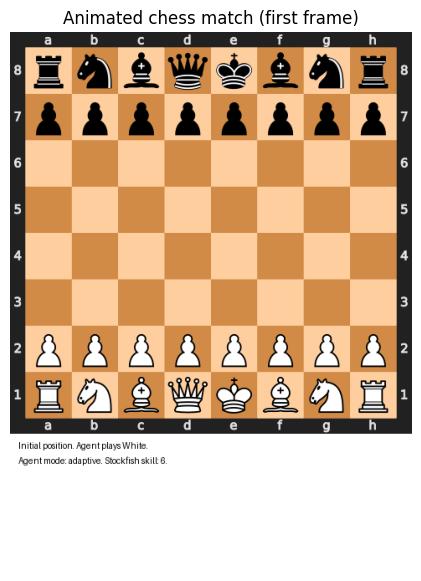

Open the GIF file directly from the notebook file browser for animation.


In [ ]:
show_image(short_match["gif_path"], title="Animated chess match (first frame)", figsize=(7, 7))
print("Open the GIF file directly from the notebook file browser for animation.")


In [ ]:
# Optional full run.
# Uncomment only when you really want the full game artifact.

full_match = play_vlm_vs_stockfish(
    agent_color=chess.WHITE,
    chess_agent_mode="adaptive",
    max_plies=80,
    stockfish_skill=6,
    stockfish_time_limit=0.06,
)
print(full_match["gif_path"])
full_match["move_df"]


/content/vlm_agent_workflows/chess/vlm_vs_stockfish_white_adaptive.gif


,ply,actor,move_san,move_uci,source,fallback_used
0,1,agent,e4,e2e4,pure_vision,False
1,2,stockfish,e6,e7e6,stockfish,False
2,3,agent,Nf3,g1f3,adaptive_with_legal_list,False
3,4,stockfish,c5,c7c5,stockfish,False
4,5,agent,Nc3,b1c3,adaptive_with_legal_list,False
5,6,stockfish,d6,d7d6,stockfish,False
6,7,agent,Nb5,c3b5,adaptive_with_legal_list,False
7,8,stockfish,e5,e6e5,stockfish,False
8,9,agent,Nc3,b5c3,adaptive_with_legal_list,False
9,10,stockfish,g6,g7g6,stockfish,False


# Example 2 — Web research agent

This example uses the same open VLM in **text-only mode**.

The workflow is explicit and easy to explain:

1. search the web,
2. choose 2 results to inspect first,
3. fetch page text,
4. summarize each page into notes,
5. decide whether the answer is already good enough,
6. otherwise inspect one more page,
7. stop after confidence is high or after 5 pages.



In [ ]:
# Web-research utilities
WEB_SYSTEM_PROMPT = (
    "You are a careful research assistant. "
    "Use only the provided evidence. Return short, structured answers."
)

USER_AGENT = (
    "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 "
    "(KHTML, like Gecko) Chrome/122.0 Safari/537.36"
)


def search_web(query: str, max_results: int = 8) -> List[Dict[str, str]]:
    results = DDGS().text(query, max_results=max_results)
    cleaned = []
    seen = set()
    for item in results:
        href = item.get("href")
        if not href or href in seen:
            continue
        seen.add(href)
        cleaned.append(
            {
                "title": item.get("title", ""),
                "href": href,
                "body": item.get("body", ""),
            }
        )
    return cleaned


def fetch_page_text(url: str, timeout: int = 20, max_chars: int = 8000) -> str:
    try:
        response = requests.get(url, timeout=timeout, headers={"User-Agent": USER_AGENT})
        response.raise_for_status()
        html = response.text
    except Exception as exc:
        return f"[FETCH_ERROR] {exc}"

    extracted = trafilatura.extract(
        html,
        include_links=False,
        include_comments=False,
        favor_precision=True,
        output_format="txt",
    )
    if extracted:
        return truncate(extracted, max_chars=max_chars)

    soup = BeautifulSoup(html, "lxml")
    text = soup.get_text(" ", strip=True)
    return truncate(text, max_chars=max_chars)


def format_search_results_for_model(results: List[Dict[str, str]]) -> str:
    lines = []
    for idx, item in enumerate(results):
        lines.append(
            f"[{idx}] {item['title']}\nURL: {item['href']}\nSnippet: {truncate(item['body'], 240)}"
        )
    return "\n\n".join(lines)


In [ ]:
#

def choose_initial_results(query: str, results: List[Dict[str, str]]) -> List[int]:
    prompt = f"""
User query: {query}

Search results:
{format_search_results_for_model(results)}

Pick exactly 2 result indices to inspect first.
Prefer official docs, strong technical explainers, or primary sources.
Return valid JSON only:
{{"selected_indices": [0, 1], "reason": "..."}}
""".strip()
    raw = ask_model(prompt, system_prompt=WEB_SYSTEM_PROMPT, max_new_tokens=180)
    obj = extract_json_object(raw) or {}
    indices = obj.get("selected_indices", []) if isinstance(obj, dict) else []
    valid = []
    for idx in indices:
        if isinstance(idx, int) and 0 <= idx < len(results) and idx not in valid:
            valid.append(idx)
    if len(valid) < 2:
        for idx in range(min(2, len(results))):
            if idx not in valid:
                valid.append(idx)
    return valid[:2]


def summarize_page_for_query(query: str, title: str, url: str, page_text: str) -> Dict[str, Any]:
    prompt = f"""
User query: {query}
Page title: {title}
URL: {url}

Page text:
{page_text}

Summarize only what is useful for answering the query.
Return valid JSON only:
{{
  "relevance": "high|medium|low",
  "key_points": ["...", "..."],
  "answer_contribution": "..."
}}
""".strip()
    raw = ask_model(prompt, system_prompt=WEB_SYSTEM_PROMPT, max_new_tokens=280)
    obj = extract_json_object(raw) or {}
    if not isinstance(obj, dict):
        obj = {}
    key_points = obj.get("key_points")
    if not isinstance(key_points, list):
        key_points = [truncate(raw, 500)]
    return {
        "relevance": obj.get("relevance", "unknown"),
        "key_points": [str(x) for x in key_points[:6]],
        "answer_contribution": str(obj.get("answer_contribution", truncate(raw, 500))),
        "raw": raw,
    }


def decide_next_action(
    query: str,
    notes: List[Dict[str, Any]],
    remaining_results: List[Dict[str, Any]],
    min_pages_before_stop: int = 2,
) -> Dict[str, Any]:
    visited_block = []
    for idx, note in enumerate(notes):
        visited_block.append(
            f"Visited #{idx}: {note['title']}\nURL: {note['href']}\nSummary: {note['summary']['answer_contribution']}\nKey points: {note['summary']['key_points']}"
        )
    remaining_block = format_search_results_for_model(remaining_results) if remaining_results else "<none>"

    prompt = f"""
User query: {query}

Visited pages:
{'\n\n'.join(visited_block)}

Remaining candidate results:
{remaining_block}

Decide whether we already have enough evidence.
If yes, return action = stop.
If not, choose exactly one next result index from the remaining result list shown above.
Return valid JSON only:
{{"action": "stop|visit", "next_index": 0, "reason": "..."}}
""".strip()
    raw = ask_model(prompt, system_prompt=WEB_SYSTEM_PROMPT, max_new_tokens=220)
    obj = extract_json_object(raw) or {}
    if not isinstance(obj, dict):
        obj = {}

    action = obj.get("action", "visit")
    next_index = obj.get("next_index", None)
    if len(notes) < min_pages_before_stop:
        action = "visit"
    if action not in {"stop", "visit"}:
        action = "visit"
    if action == "visit" and not isinstance(next_index, int):
        next_index = 0 if remaining_results else None
    return {
        "action": action,
        "next_index": next_index,
        "reason": obj.get("reason", truncate(raw, 300)),
        "raw": raw,
    }


def synthesize_final_answer(query: str, notes: List[Dict[str, Any]]) -> str:
    evidence_lines = []
    for idx, note in enumerate(notes, start=1):
        evidence_lines.append(
            f"[{idx}] {note['title']}\nURL: {note['href']}\nContribution: {note['summary']['answer_contribution']}\nKey points: {note['summary']['key_points']}"
        )

    prompt = f"""
User query: {query}

Evidence from visited pages:
{'\n\n'.join(evidence_lines)}

Write a final answer using only this evidence.
Be concise but informative.
End with a short source list using the numbered items.
""".strip()
    return ask_model(prompt, system_prompt=WEB_SYSTEM_PROMPT, max_new_tokens=420)


In [ ]:
def run_web_research_agent(query: str, max_pages: int = 5, initial_results_to_read: int = 2):
    search_results = search_web(query, max_results=8)
    if not search_results:
        raise RuntimeError("No search results were returned.")

    selected = choose_initial_results(query, search_results)
    selected = selected[:initial_results_to_read]

    visited_indices: List[int] = []
    notes: List[Dict[str, Any]] = []
    trace_rows: List[Dict[str, Any]] = []

    def visit_index(global_idx: int):
        if global_idx in visited_indices:
            return
        result = search_results[global_idx]
        page_text = fetch_page_text(result["href"])
        summary = summarize_page_for_query(query, result["title"], result["href"], page_text)
        visited_indices.append(global_idx)
        note = {
            "global_index": global_idx,
            "title": result["title"],
            "href": result["href"],
            "snippet": result["body"],
            "page_text": page_text,
            "summary": summary,
        }
        notes.append(note)
        trace_rows.append(
            {
                "step": len(trace_rows) + 1,
                "action": "visit_page",
                "result_index": global_idx,
                "title": result["title"],
                "url": result["href"],
                "relevance": summary["relevance"],
                "answer_contribution": summary["answer_contribution"],
            }
        )

    for idx in selected:
        visit_index(idx)

    while len(visited_indices) < max_pages:
        remaining = [
            {**result, "global_index": idx}
            for idx, result in enumerate(search_results)
            if idx not in visited_indices
        ]
        if not remaining:
            break

        decision = decide_next_action(query, notes, remaining)
        trace_rows.append(
            {
                "step": len(trace_rows) + 1,
                "action": "decide",
                "result_index": decision.get("next_index"),
                "title": "<decision>",
                "url": "",
                "relevance": "",
                "answer_contribution": decision["reason"],
            }
        )
        if decision["action"] == "stop":
            break

        remaining_idx = decision.get("next_index", 0)
        if not isinstance(remaining_idx, int) or not (0 <= remaining_idx < len(remaining)):
            remaining_idx = 0
        visit_index(remaining[remaining_idx]["global_index"])

    final_answer = synthesize_final_answer(query, notes)
    trace_df = pd.DataFrame(trace_rows)
    sources_df = pd.DataFrame(
        [
            {
                "visited_order": i + 1,
                "global_search_index": note["global_index"],
                "title": note["title"],
                "url": note["href"],
                "relevance": note["summary"]["relevance"],
            }
            for i, note in enumerate(notes)
        ]
    )

    return {
        "query": query,
        "search_results": search_results,
        "visited_notes": notes,
        "trace_df": trace_df,
        "sources_df": sources_df,
        "final_answer": final_answer,
    }


In [ ]:
RESEARCH_QUERY = "Где люди зарабатывают больше всего?"
# Change the query to whatever you want to demo live.

research_run = run_web_research_agent(RESEARCH_QUERY, max_pages=5, initial_results_to_read=2)
display(Markdown("## Final answer\n\n" + research_run["final_answer"]))
research_run["sources_df"]


## Final answer

Люди зарабатывают больше всего в США и Канаде (средние зарплаты $82 000 и $80 000 соответственно). В России — в Москве, Санкт-Петербурге и Московской области, особенно в сфере IT и нефтегазовой отрасли. В мире — в городах с высокой стоимостью жизни: Зюрих ($5 764), Сан-Франциско и Нью-Йорк.

Источники: [2], [3], [4], [5]

,visited_order,global_search_index,title,url,relevance
0,1,0,"Зарплаты россиян: кто получает больше 100, 500...",https://t-j.ru/short/zarplata-bolsche-x/,low
1,2,1,Профессии с высокой зарплатой: где много платя...,https://journal.sovcombank.ru/rabota/zarplata-...,unknown
2,3,4,"28 крупнейших городов мира, где работники полу...",https://tr-page.yandex.ru/translate?lang=en-ru...,high
3,4,6,Где люди зарабатывают больше всего: рейтинг ст...,https://www.pravda.ru/news/economics/2005990-z...,high
4,5,5,Сколько человек в России получают зарплату бол...,https://finuslugi.ru/navigator/kak-ehto-rabota...,high


In [ ]:
research_run["trace_df"]


,step,action,result_index,title,url,relevance,answer_contribution
0,1,visit_page,0,"Зарплаты россиян: кто получает больше 100, 500...",https://t-j.ru/short/zarplata-bolsche-x/,low,Unable to retrieve content due to unauthorized...
1,2,visit_page,1,Профессии с высокой зарплатой: где много платя...,https://journal.sovcombank.ru/rabota/zarplata-...,unknown,"{ ""relevance"": ""high"", ""key_points"": [ ""Самые ..."
2,3,decide,2,<decision>,,,The result provides a global ranking of cities...
3,4,visit_page,4,"28 крупнейших городов мира, где работники полу...",https://tr-page.yandex.ru/translate?lang=en-ru...,high,Zurich leads in highest average monthly earnin...
4,5,decide,3,<decision>,,,The remaining result at index 3 provides a glo...
5,6,visit_page,6,Где люди зарабатывают больше всего: рейтинг ст...,https://www.pravda.ru/news/economics/2005990-z...,high,США и Канада — страны с самыми высокими зарпла...
6,7,decide,2,<decision>,,,To determine where people earn the most global...
7,8,visit_page,5,Сколько человек в России получают зарплату бол...,https://finuslugi.ru/navigator/kak-ehto-rabota...,high,Наиболее высокие зарплаты в России получают ра...


In [ ]:
RESEARCH_QUERY = "Самый богатый человек в мире?"
# Change the query to whatever you want to demo live.

research_run = run_web_research_agent(RESEARCH_QUERY, max_pages=5, initial_results_to_read=2)
display(Markdown("## Final answer\n\n" + research_run["final_answer"]))
research_run["sources_df"]


## Final answer

На 4 февраля 2026 года самым богатым человеком в мире является Илон Маск с состоянием $852 млрд. Он стал богатейшим человеком в мире 7 января 2021 года, сместив Джеффа Безоса, и первым в истории, чьё состояние превысило 800 млрд долларов.

Источники: [1], [2]

,visited_order,global_search_index,title,url,relevance
0,1,0,"Маск, Илон — Википедия","https://ru.wikipedia.org/wiki/Маск,_Илон",high
1,2,1,Илон Маск стал первым в мире человеком... — Th...,https://theins.ru/news/285482,high
